<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula02e%20adaline%20with%20normal%20equation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

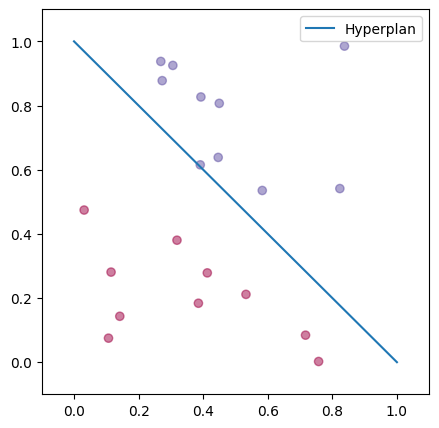

In [149]:
import numpy as np
import matplotlib.pyplot as plt

def createDataset(n=20):
  X = np.random.rand(n,2)
  coefs = np.array([1, 1])
  intercept = 1
  labels = X @ coefs - intercept
  y = np.array(labels>0, dtype=int)*2-1
  return X, y

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y, cmap="Spectral", alpha=0.5)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.1,1.1)

def plotHyperplan(vector, intercept, legend="Hyperplan"):
  xs = np.array([0,1])
  ys = -(vector[0]*xs + intercept)/vector[1]
  plt.plot(xs, ys, label=legend)
  plt.legend()

X, y = createDataset()
plotDataset(X, y)
plotHyperplan(np.array([1, 1]), -1)
plt.show()

RMSE: 0.4148649623630678
Weights: [-1.76182605  1.00641274  2.74360748]


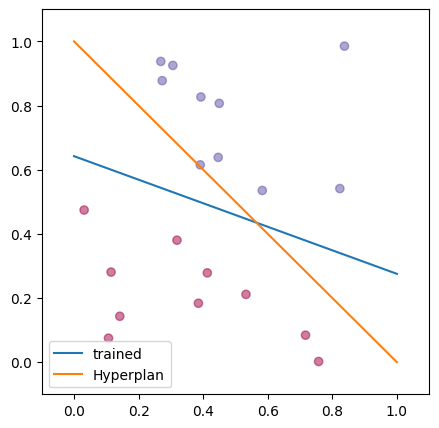

In [158]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import root_mean_squared_error

def include_bias(X):
  return np.hstack((np.ones((X.shape[0],1)), X))

class AdalinePseudoInverse(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    X = include_bias(X)
    self.w_ = np.linalg.pinv(X) @ y
    return self

  def predict(self, X):
    X = include_bias(X)
    return X @ self.w_


clf = AdalinePseudoInverse()
clf.fit(X, y)
y_pred = clf.predict(X)
print(f"RMSE: {root_mean_squared_error(y, y_pred)}")
print(f"Weights: {clf.w_}")
plotDataset(X, y)
plotHyperplan(clf.w_[1:], clf.w_[0], legend="trained")
plotHyperplan(np.array([1, 1]), -1)
plt.show()

Accuracy: 1.0
Weights: [-1.76182605  1.00641274  2.74360748]


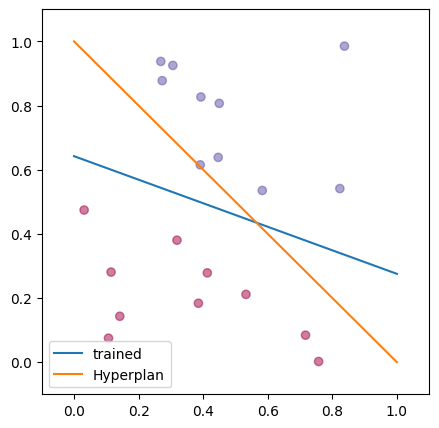

In [159]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.hstack((np.ones((X.shape[0],1)), X))

class AdalinePseudoInverse(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    X = include_bias(X)
    self.w_ = np.linalg.pinv(X) @ y
    return self

  def pre_activation(self, X):
    X = include_bias(X)
    return X @ self.w_

  def predict(self, X):
    return np.sign(self.pre_activation(X))

clf = AdalinePseudoInverse()
clf.fit(X, y)
y_pred = clf.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {clf.w_}")
plotDataset(X, y)
plotHyperplan(clf.w_[1:], clf.w_[0], legend="trained")
plotHyperplan(np.array([1, 1]), -1)
plt.show()